## Adaptive clustering from samplet coefficients

The samplet coefficients say *where* a function is rough. Feeding that information back into the
cluster tree gives an **adaptive partition** of the point cloud: fine clusters where the data
varies, coarse clusters where it does not.

FMCA implements the second Binev&ndash;DeVore tree-search algorithm: it greedily activates the
clusters carrying the most energy until the remaining energy falls below a tolerance. The
*leaves* of the resulting adaptive tree are the clusters of the partition.

```python
labels = ST.adaptiveTreeLeafPartition(data, thres)   # one label per point
boxes  = ST.adaptiveTreeLeafBoxes(data, thres)       # (2*dim) x nleaf bounding boxes
```

`thres` is relative to the energy of the data, so it is scale independent.

In [19]:
# the KMP setting avoids a clash between the OpenMP runtimes of FMCA and numpy
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import numpy as np
import matplotlib.pyplot as plt
import FMCA

plt.rcParams.update({
    "figure.dpi": 80,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})
C_DATA, C_SAMP, C_REF = "#1f4e79", "#c1121f", "#2a9d8f"

In [20]:
from matplotlib.patches import Rectangle

def draw_boxes(ax, boxes, **kw):
    """boxes is (2*dim) x nleaf: [lower corner; upper corner] per column"""
    d = boxes.shape[0] // 2
    for j in range(boxes.shape[1]):
        lo, hi = boxes[:d, j], boxes[d:, j]
        ax.add_patch(Rectangle(lo, *(hi - lo), fill=False, **kw))

## The data

Scattered points in 2D, and a function with a smooth background plus two sharp localised bumps.

100000 points, 9381 clusters in the tree


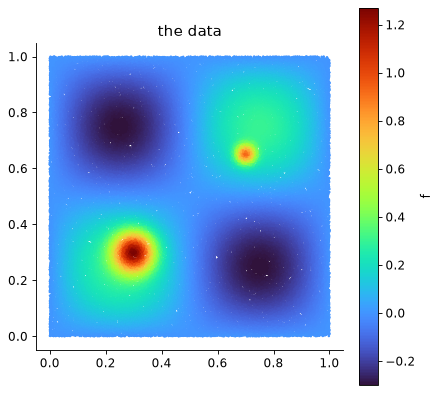

In [21]:
rng = np.random.default_rng(3)
N = 100000
P = np.array(rng.random((2, N)), order="F")
x, y = P[0], P[1]
f = (np.exp(-200 * ((x - 0.30) ** 2 + (y - 0.30) ** 2))
     + 0.7 * np.exp(-800 * ((x - 0.70) ** 2 + (y - 0.65) ** 2))
     + 0.3 * np.sin(2 * np.pi * x) * np.sin(2 * np.pi * y))

ST = FMCA.SampletTree(P, 3)
print(f"{N} points, {ST.nclusters()} clusters in the tree")

plt.figure(figsize=(5.4, 4.8))
plt.scatter(x, y, c=f, s=1.4, cmap="turbo")
plt.colorbar(label="f")
plt.gca().set_aspect("equal")
plt.grid(False)
plt.title("the data")
plt.show()

## For reference: the *uniform* clustering

`ST.levelBoxes(lvl)` and `ST.levelLabels(lvl)` expose the clusters of the tree level by level.
This is the non-adaptive partition &mdash; it refines everywhere, whether the data needs it or not.

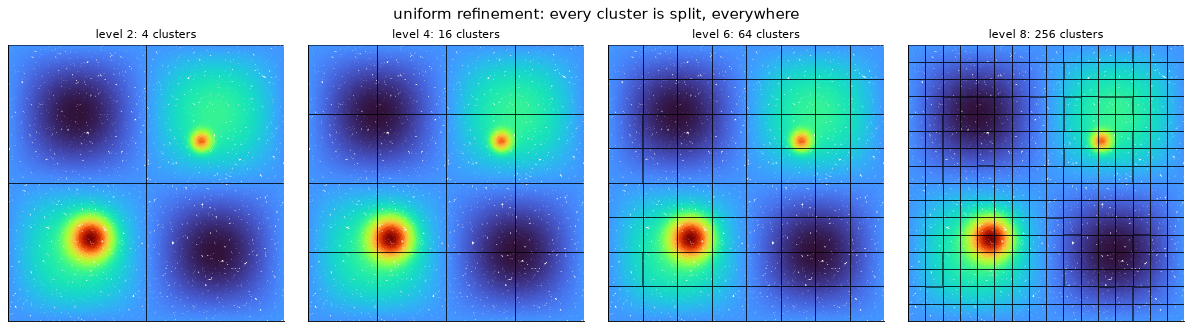

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, lvl in zip(axes, [2, 4, 6, 8]):
    boxes = ST.levelBoxes(lvl)
    ax.scatter(x, y, c=f, s=0.7, cmap="turbo")
    draw_boxes(ax, boxes, ec="k", lw=0.5)
    ax.set_title(f"level {lvl}: {boxes.shape[1]} clusters", fontsize=10)
    ax.set_aspect("equal")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("uniform refinement: every cluster is split, everywhere")
plt.show()

## The adaptive partition

Now the same tree, but only the clusters the *data* asks for.

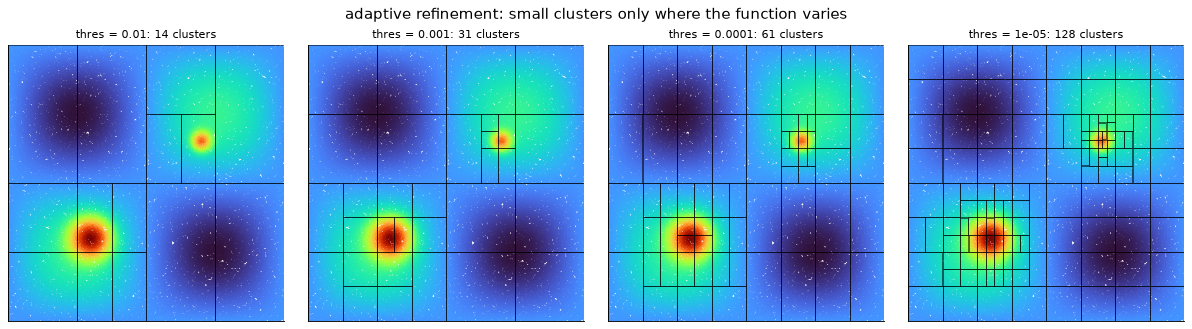

In [23]:
thresholds = [1e-2, 1e-3, 1e-4, 1e-5]
fig, axes = plt.subplots(1, len(thresholds), figsize=(15, 4))
for ax, thr in zip(axes, thresholds):
    labels = ST.adaptiveTreeLeafPartition(f, thr)
    boxes = ST.adaptiveTreeLeafBoxes(f, thr)
    ax.scatter(x, y, c=f, s=0.7, cmap="turbo")
    draw_boxes(ax, boxes, ec="k", lw=0.5)
    ax.set_title(f"thres = {thr:g}: {boxes.shape[1]} clusters", fontsize=10)
    ax.set_aspect("equal")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("adaptive refinement: small clusters only where the function varies")
plt.show()

The labels themselves are what you would feed to a downstream algorithm &mdash; a local solver, a
local model, a domain decomposition. Every point gets exactly one label, so the leaves really do
form a partition.

## Random projection trees

`FMCA.SampletTreeRP` builds the same machinery on a *random projection* tree: clusters are split
along random directions instead of coordinate axes. The API is identical.

Because the splits are not axis aligned, the axis-aligned bounding boxes of the leaves overlap,
so here the partition is shown through the point colours only.

random projection tree: 8191 clusters


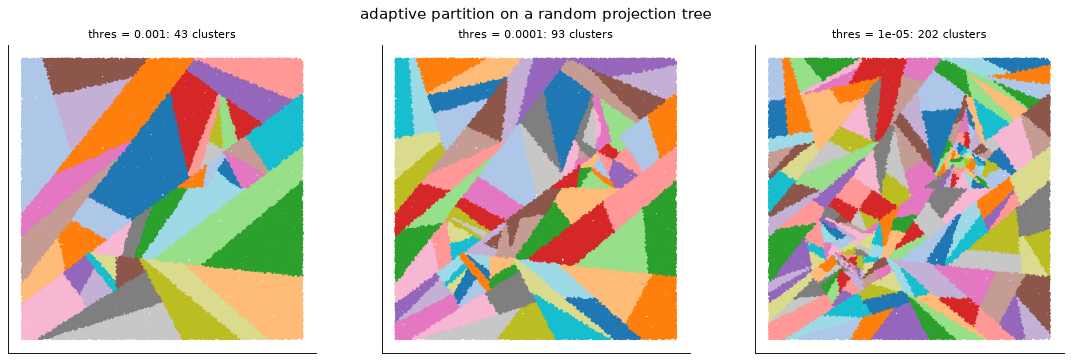

In [24]:
STrp = FMCA.SampletTreeRP(P, 3, 0)          # third argument: random seed
print(f"random projection tree: {STrp.nclusters()} clusters")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, thr in zip(axes, [1e-3, 1e-4, 1e-5]):
    lab = STrp.adaptiveTreeLeafPartition(f, thr)
    ax.scatter(x, y, c=lab % 20, s=1.6, cmap="tab20")
    ax.set_title(f"thres = {thr:g}: {lab.max() + 1} clusters", fontsize=10)
    ax.set_aspect("equal")
    ax.grid(False); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("adaptive partition on a random projection tree")
plt.show()